# Exploratory Data Analysis: Assembly Data Report
This notebook conducts Exploratory Data Analysis (EDA) on the `assembly_data_report.csv` dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Loading the Data

In [3]:
# Load the dataset
# Note: the notebook is in the 'scripts' directory, so the file is one level up
df = pd.read_csv('../assembly_data_report.csv')
df.head()

,accession,assembly_level,assembly_name,submitter,total_sequence_length,gc_percent,taxid,organism_name,release_date
0,GCA_000320725.1,Contig,APLentillevirus_1.0,CNRS UMR IRD 6236,1193433,28.0,1077221,Acanthamoeba polyphaga lentillevirus,2012-07-27
1,GCA_000847085.1,Complete Genome,ViralProj14573,"M. Jaeger, Dept of Virology, University of Ulm...",4491,33.5,1977403,Acholeplasma phage MV-L51,1993-04-21
2,GCA_000848265.1,Complete Genome,ViralProj14654,"NIH, NLM",5894,55.0,11788,Abelson murine leukemia virus,1998-01-22
3,GCA_000850225.1,Complete Genome,ViralProj14710,"BMC, University of Latvia",4268,44.0,154784,Acinetobacter phage AP205,2003-01-30
4,GCA_000858405.1,Complete Genome,ViralProj15222,NaN,5234,40.0,185639,Acheta domestica densovirus,2002-02-04


## 2. Basic Information

In [4]:
# Dataset shape and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 272515 entries, 0 to 272514
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   accession              272515 non-null  str    
 1   assembly_level         272515 non-null  str    
 2   assembly_name          272515 non-null  str    
 3   submitter              271759 non-null  str    
 4   total_sequence_length  272515 non-null  int64  
 5   gc_percent             272515 non-null  float64
 6   taxid                  272515 non-null  int64  
 7   organism_name          272515 non-null  str    
 8   release_date           272515 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 18.7 MB


In [5]:
# Summary statistics for numerical columns
df.describe()

,total_sequence_length,gc_percent,taxid
count,2.725150e+05,272515.000000,2.725150e+05
mean,3.401432e+04,43.628850,9.817468e+05
std,2.205301e+06,6.185211,1.102708e+06
min,1.200000e+01,18.000000,1.024300e+04
25%,1.313300e+04,41.000000,1.132000e+04
50%,1.342600e+04,43.000000,3.007400e+05
75%,2.349400e+04,44.500000,2.014202e+06
max,1.150678e+09,78.500000,3.458551e+06


## 3. Missing Values

In [6]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

submitter    756
dtype: int64

<class 'pandas.Series'>


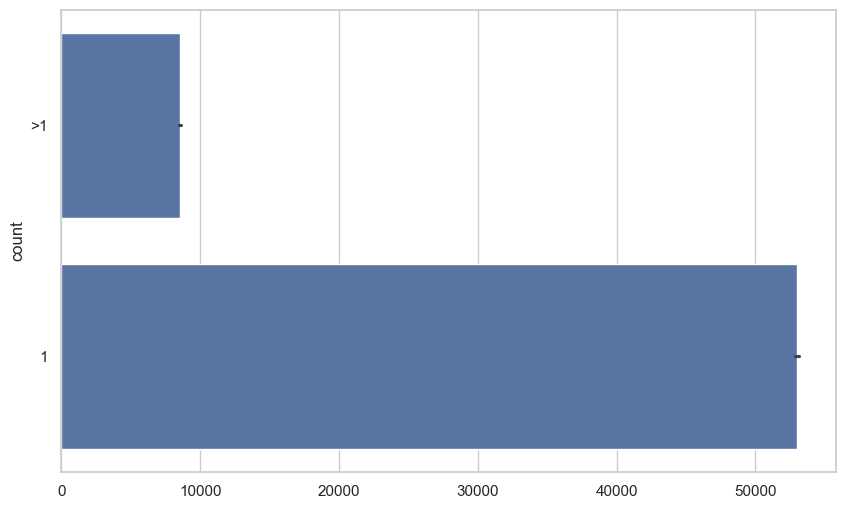

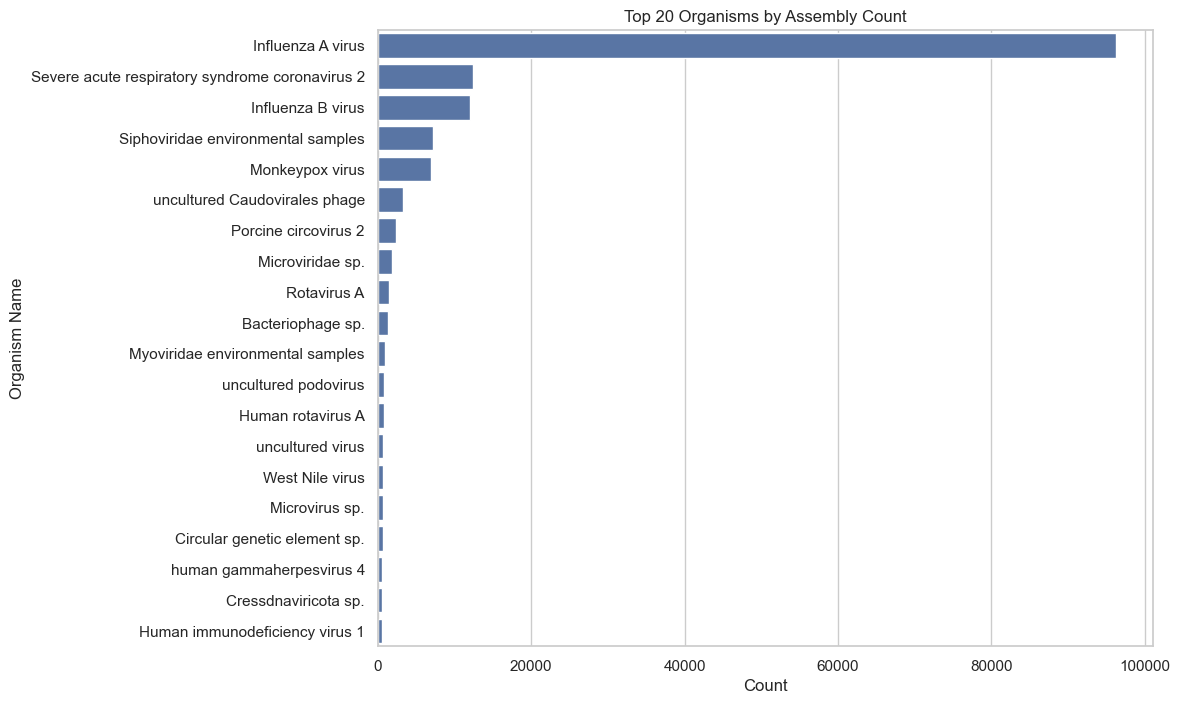

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

# Counting occurrences of each taxid
taxid_counts = df['taxid'].value_counts().reset_index()
taxid_counts.columns = ['taxid', 'count']

median_count = taxid_counts['count'].median()
print(type(taxid_counts['count']))

sns.barplot(taxid_counts['count'].map(lambda x: '1' if x == 1 else '>1'))
# Mapping taxid back to organism_name
taxid_map = df[['taxid', 'organism_name']].drop_duplicates('taxid')
plot_df = taxid_counts.merge(taxid_map, on='taxid')

# Plotting the top 20 organisms by count
plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df.head(20), x='count', y='organism_name')
plt.title('Top 20 Organisms by Assembly Count')
plt.xlabel('Count')
plt.ylabel('Organism Name')
plt.show()



## 4. Categorical Data: Assembly Level

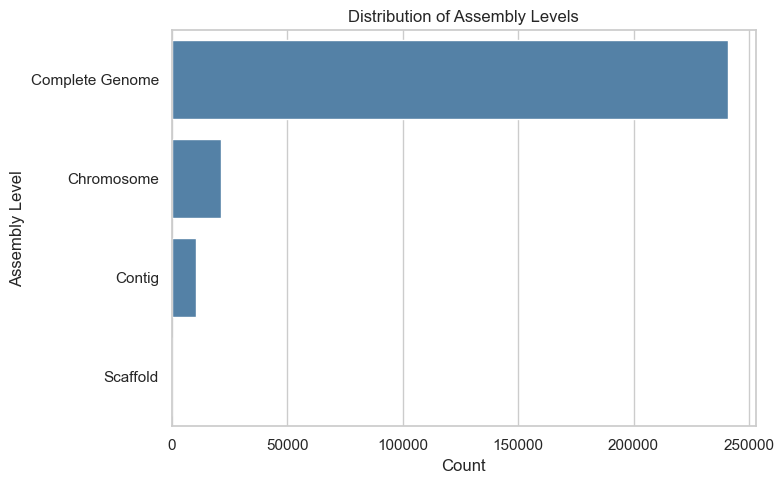

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='assembly_level', order=df['assembly_level'].value_counts().index, color='steelblue')
plt.title('Distribution of Assembly Levels')
plt.xlabel('Count')
plt.ylabel('Assembly Level')
plt.tight_layout()
plt.show()

## 5. Numerical Data: Sequence Length and GC Percent

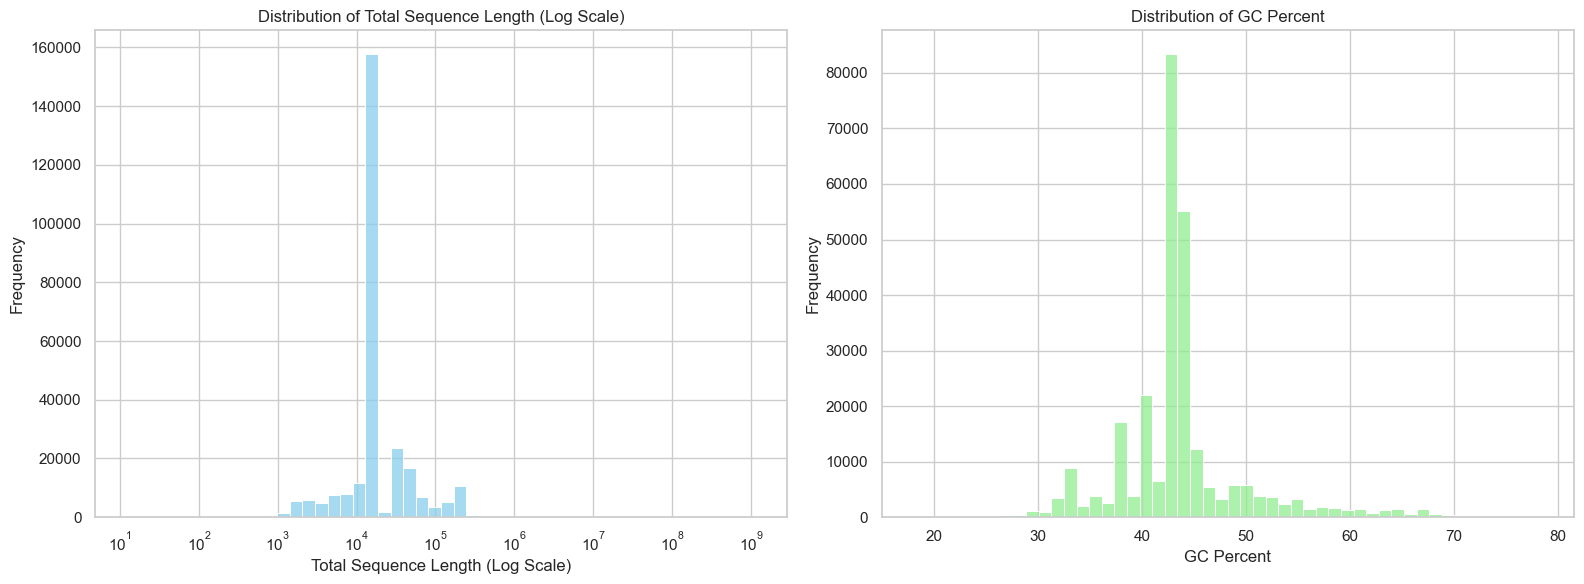

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total Sequence Length (Log Scale since length varies widely)
sns.histplot(df['total_sequence_length'], bins=50, log_scale=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Total Sequence Length (Log Scale)')
axes[0].set_xlabel('Total Sequence Length (Log Scale)')
axes[0].set_ylabel('Frequency')

# GC Percent
gc_data = df['gc_percent'].replace('na', np.nan).dropna().astype(float)
sns.histplot(gc_data, bins=50, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribution of GC Percent')
axes[1].set_xlabel('GC Percent')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Relationships: GC Percent vs Sequence Length

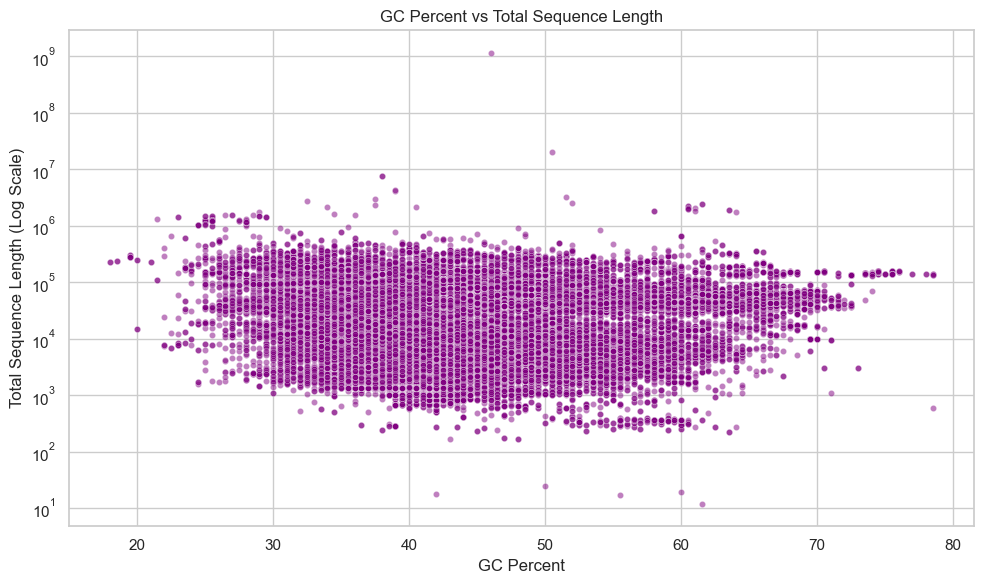

In [9]:
plt.figure(figsize=(10, 6))
# Convert gc_percent to float safely
df_clean = df.copy()
df_clean['gc_percent'] = pd.to_numeric(df_clean['gc_percent'], errors='coerce')
df_clean = df_clean.dropna(subset=['gc_percent', 'total_sequence_length'])

sns.scatterplot(data=df_clean, x='gc_percent', y='total_sequence_length', alpha=0.5, color='purple', s=20)
plt.yscale('log')
plt.title('GC Percent vs Total Sequence Length')
plt.xlabel('GC Percent')
plt.ylabel('Total Sequence Length (Log Scale)')
plt.tight_layout()
plt.show()

## 7. Submitters Analysis

In [ ]:
top_submitters = df['submitter'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_submitters.values, y=top_submitters.index, color='coral')
plt.title('Top 10 Submitters')
plt.xlabel('Number of Assemblies')
plt.ylabel('Submitter')
plt.tight_layout()
plt.show()

## 8. Trends Over Time

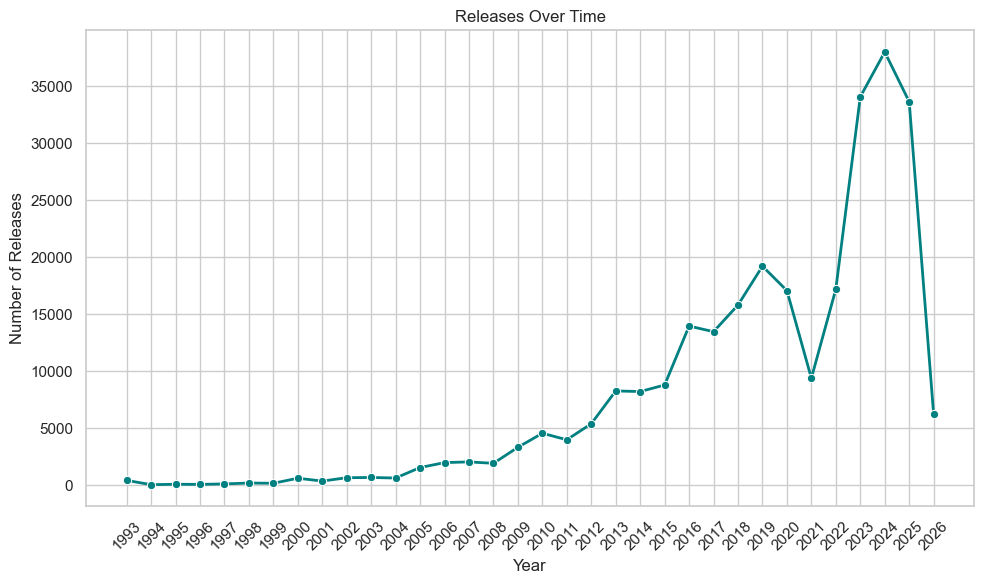

In [10]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

plt.figure(figsize=(10, 6))
year_counts = df['release_year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='teal', linewidth=2)
plt.title('Releases Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(year_counts.index.astype(int), rotation=45)
plt.tight_layout()
plt.show()